In [1]:
seq = list("gataggattatcattcataagtttcagagcaatgtccttattctggaacttggatttatggctcttttggtttaatttcgcctgattcttgatctcctttagcttctcgacgtgggcctttttcttgccatatggatccgctgcacggtcctgttccctagcatgtacgtgagcgtatttccttttaaaccacgacgctttgcttcattcaacgtttcccattgtttttttctactattgctttgctgtgggaaaaacttatcgaaagatgacgactttttcttaattctcgttttaagagcttggtgagcgctaggagtcactgccag")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

##Автомат модели:

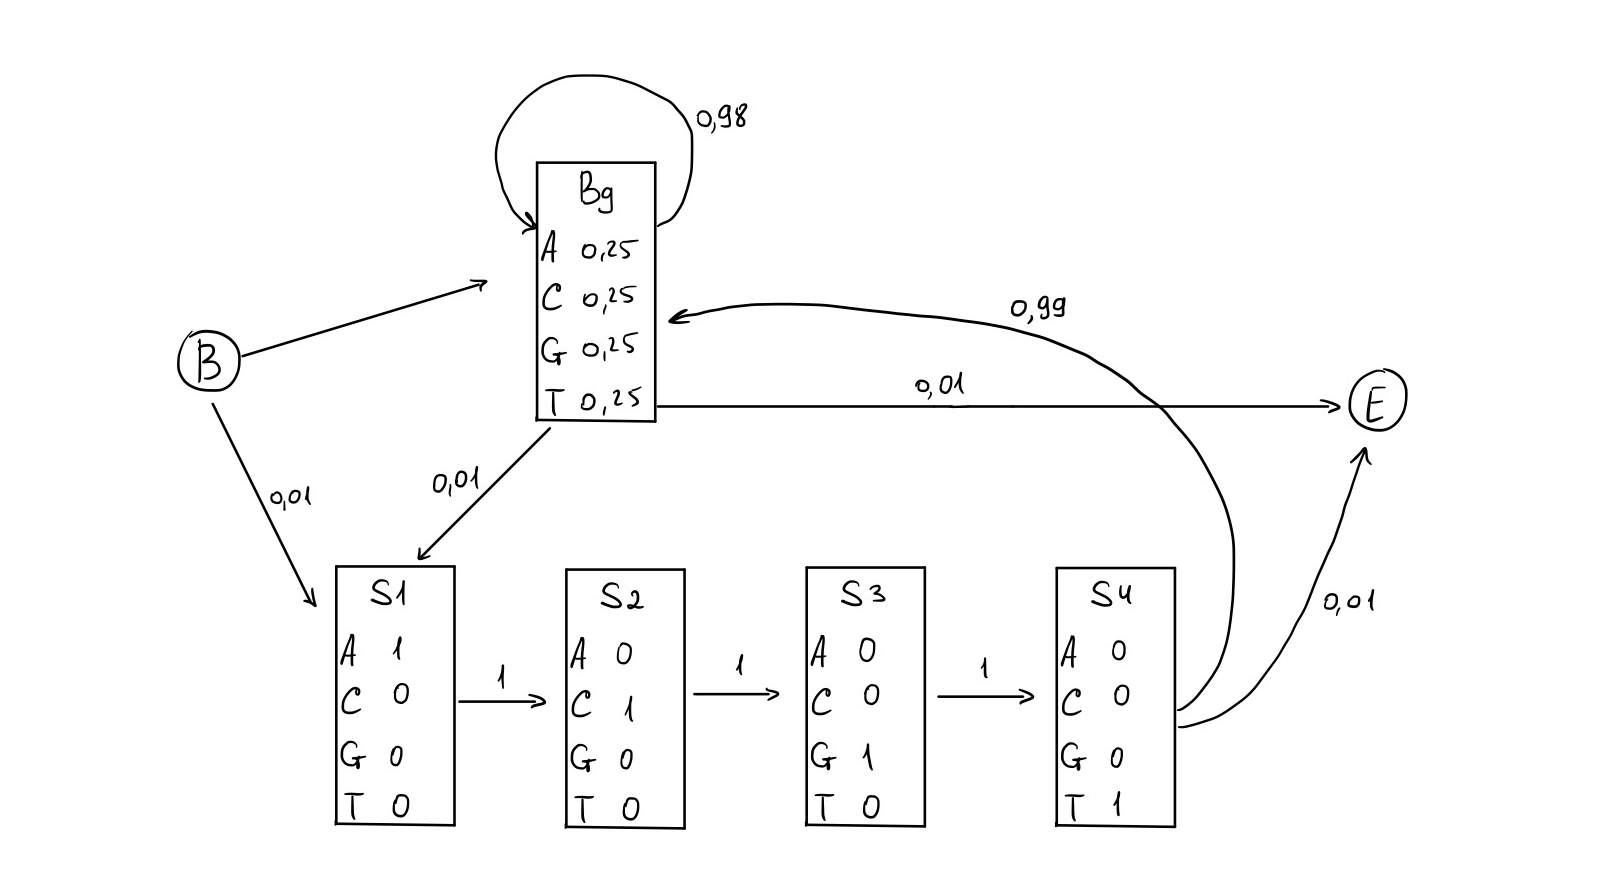

##Витерби

Алгоритм Витерби (для a(Bg → site)=0.01):

In [3]:
#setting possible states
states = ['Bg', 'S1', 'S2', 'S3', 'S4']

#probability of generating a symbol in the state
emission = {
    'Bg': {'a': 0.25, 'c': 0.25, 'g': 0.25, 't': 0.25},
    'S1': {'a': 1.0, 'c': 0.0, 'g': 0.0, 't': 0.0},
    'S2': {'a': 0.0, 'c': 1.0, 'g': 0.0, 't': 0.0},
    'S3': {'a': 0.0, 'c': 0.0, 'g': 1.0, 't': 0.0},
    'S4': {'a': 0.0, 'c': 0.0, 'g': 0.0, 't': 1.0},
}

#setting transition probabilities Bg->site=0.01
def get_transitions(p=0.01):
    return {
        'Bg': {'Bg': 1 - p - 0.01, 'S1': p},  # Bg → Bg, S1
        'S1': {'S2': 1.0},
        'S2': {'S3': 1.0},
        'S3': {'S4': 1.0},
        'S4': {'Bg': 0.99},  # S4 → Bg
    }

#viterbi algorithm
def viterbi(seq, p_bg_to_site=0.01):
    T = len(seq) #sequence length
    transitions = get_transitions(p_bg_to_site)
    V = {s: np.full(T, -np.inf) for s in states} #max probability of hitting the state in a step
    back = {s: [None]*T for s in states} #where did we come from in current state
    V['Bg'][0] = emission['Bg'][seq[0]] #setting first state Bg, probability to get first symbol

    #cycle by positions
    for t in range(1, T):
        x = seq[t] #current symbol
        for curr in states:
            best_prob = -np.inf #max probability to get to current state
            best_prev = None #where came from
            for prev in states:
                #checking posibility of transition
                if prev in transitions and curr in transitions[prev]:
                    if curr in emission and x in emission[curr]:
                        prob = V[prev][t-1] * transitions[prev][curr] * emission[curr][x] #probability of path to current state
                        if prob > best_prob:
                          best_prob = prob
                          best_prev = prev
            V[curr][t] = best_prob #best probability and back path
            back[curr][t] = best_prev

    #finding best final state
    last_state = max(states, key=lambda s: V[s][-1])
    path = [last_state] #restoring the path
    for t in range(T - 1, 0, -1):
        last_state = back[last_state][t]
        path.insert(0, last_state)

    return path

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
result = viterbi(seq)
print("".join(result))

BgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgS1S2S3S4BgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgS1S2S3S4BgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgS1S2S3S4BgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBg


Алгоритм Витерби (для a(Bg → site)=0.001):

In [5]:
#setting transition probabilities Bg->site=0.001
def get_transitions(p=0.001):
    return {
        'Bg': {'Bg': 1 - p - 0.01, 'S1': p},  # Bg → Bg, S1
        'S1': {'S2': 1.0},
        'S2': {'S3': 1.0},
        'S3': {'S4': 1.0},
        'S4': {'Bg': 0.99},  # S4 → Bg
    }

#viterbi algorithm
def viterbi(seq, p_bg_to_site=0.01):
    T = len(seq) #sequence length
    transitions = get_transitions(p_bg_to_site)
    V = {s: np.full(T, -np.inf) for s in states} #max probability of hitting the state in a step
    back = {s: [None]*T for s in states} #where did we come from in current state
    V['Bg'][0] = emission['Bg'][seq[0]] #setting first state Bg, probability to get first symbol

    #cycle by positions
    for t in range(1, T):
        x = seq[t] #current symbol
        for curr in states:
            best_prob = -np.inf #max probability to get to current state
            best_prev = None #where came from
            for prev in states:
                #checking posibility of transition
                if prev in transitions and curr in transitions[prev]:
                    if curr in emission and x in emission[curr]:
                        prob = V[prev][t-1] * transitions[prev][curr] * emission[curr][x] #probability of path to current state
                        if prob > best_prob:
                          best_prob = prob
                          best_prev = prev
            V[curr][t] = best_prob #best probability and back path
            back[curr][t] = best_prev

    #finding best final state
    last_state = max(states, key=lambda s: V[s][-1])
    path = [last_state] #restoring the path
    for t in range(T - 1, 0, -1):
        last_state = back[last_state][t]
        path.insert(0, last_state)

    return path

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
result = viterbi(seq)
print("".join(result))

BgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgS1S2S3S4BgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgS1S2S3S4BgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgS1S2S3S4BgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBg


При более низкой вероятности перехода модель более чувствительна, но могут быть ошибки. Если вероятность перехода 0.01, то модель считает, что раз в 100 нуклеотидов должен начаться сайт. Если вероятность равна 0.001, то раз в 1000. Это увеличивает точность, но понижает чувствительность (модель может решить, что сайт это фон). При понижении вероятности модель все чаще будет оставаться в фоне.

##Forward-Backward

Алгоритм Forward-Backward для вероятности 0,01

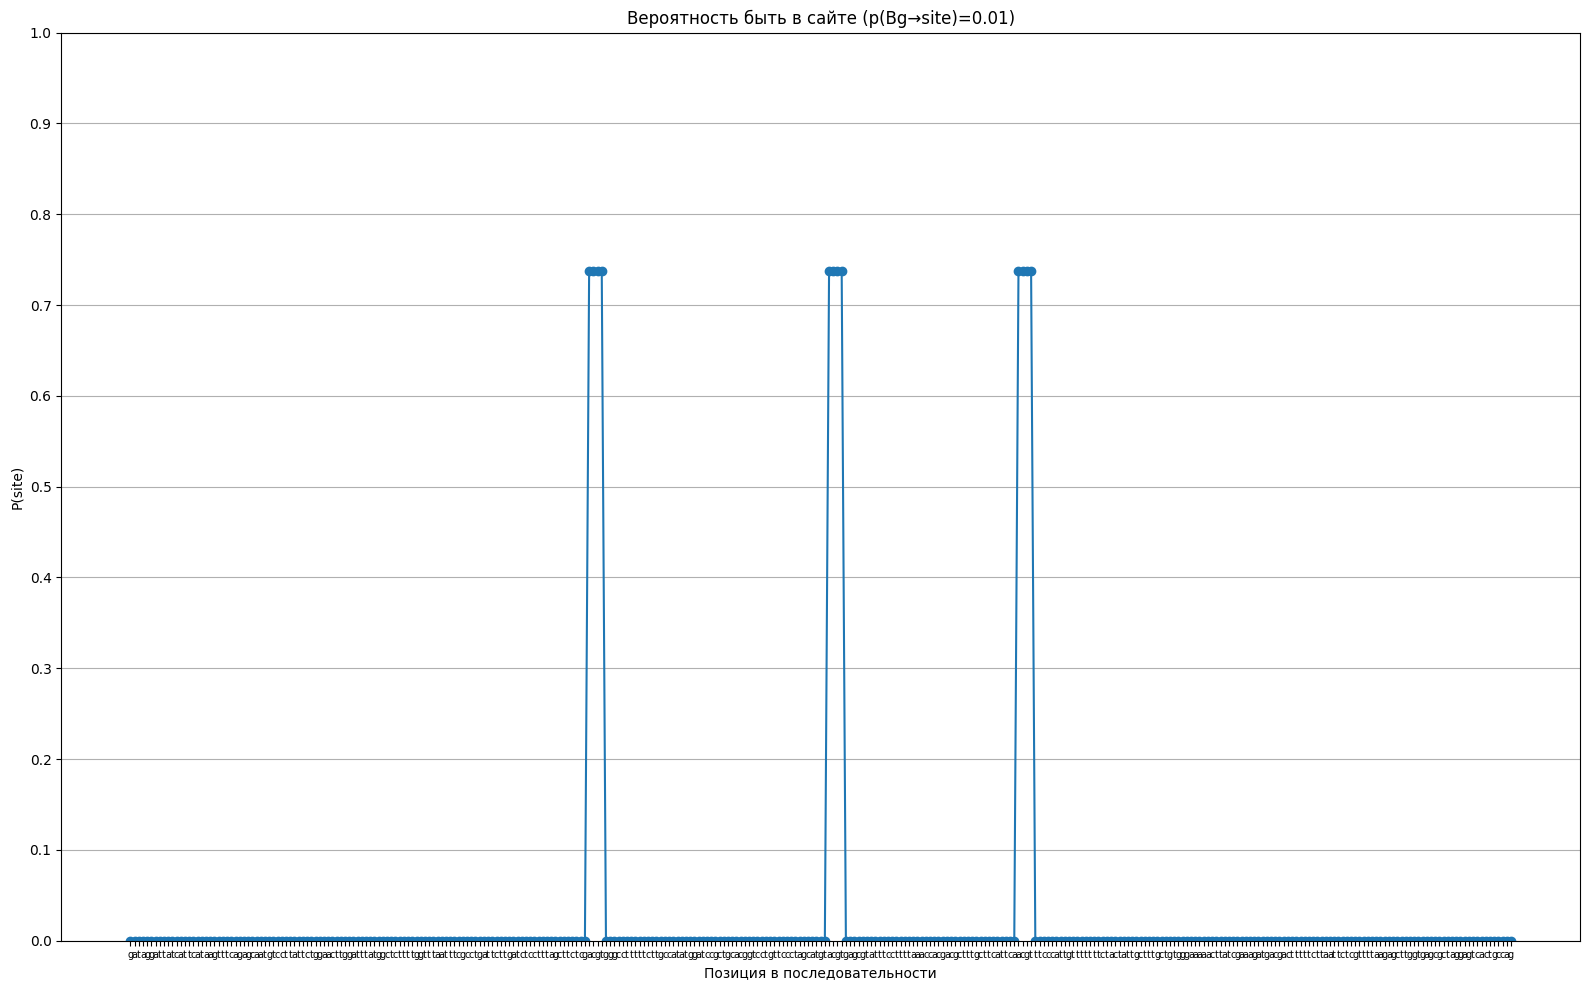

In [6]:
#setting transition probabilities Bg->site=0.01
def get_transitions(p=0.01):
    return {
        'Bg': {'Bg': 1 - p - 0.01, 'S1': p},
        'S1': {'S2': 1.0},
        'S2': {'S3': 1.0},
        'S3': {'S4': 1.0},
        'S4': {'Bg': 0.99},
    }

#algorithm forward
def forward(seq, transitions, emission):
    T = len(seq)
    alpha = {s: np.zeros(T) for s in states}
    alpha['Bg'][0] = emission['Bg'][seq[0]]

    for t in range(1, T):
        for curr in states:
            total = 0
            for prev in states:
                if prev in transitions and curr in transitions[prev]:
                    total += alpha[prev][t-1] * transitions[prev][curr]
            alpha[curr][t] = total * emission[curr].get(seq[t], 0)
    return alpha

#algorithm backward
def backward(seq, transitions, emission):
    T = len(seq)
    beta = {s: np.zeros(T) for s in states}
    for s in states:
        beta[s][T-1] = 1

    for t in reversed(range(T-1)):
        for curr in states:
            total = 0
            for next_s in states:
                if curr in transitions and next_s in transitions[curr]:
                    trans = transitions[curr][next_s]
                    emit = emission[next_s].get(seq[t+1], 0)
                    total += trans * emit * beta[next_s][t+1]
            beta[curr][t] = total
    return beta

#forward-backward
def forward_backward(seq, p_bg_to_site=0.01):
    transitions = get_transitions(p_bg_to_site)
    alpha = forward(seq, transitions, emission)
    beta = backward(seq, transitions, emission)
    T = len(seq)
    gamma = {s: np.zeros(T) for s in states}
    for t in range(T):
        norm = sum(alpha[s][t] * beta[s][t] for s in states)
        for s in states:
            gamma[s][t] = (alpha[s][t] * beta[s][t]) / (norm if norm > 0 else 1e-12)
    return gamma

#building graph
def plot_site_probabilities(seq, p=0.01):
    gamma = forward_backward(seq, p)
    site_probs = [sum(gamma[s][t] for s in ['S1', 'S2', 'S3', 'S4']) for t in range(len(seq))]

    plt.figure(figsize=(16, 10))
    plt.plot(site_probs, marker='o')
    plt.xticks(ticks=range(len(seq)), labels=seq, fontsize=7)
    plt.yticks(np.linspace(0, 1, 11))
    plt.title(f"Вероятность быть в сайте (p(Bg→site)={p})")
    plt.xlabel("Позиция в последовательности")
    plt.ylabel("P(site)")
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

plot_site_probabilities(seq, p=0.01)  # можно изменить p=0.001 или другое

Алгоритм Forward-Backward для вероятности 0,00001

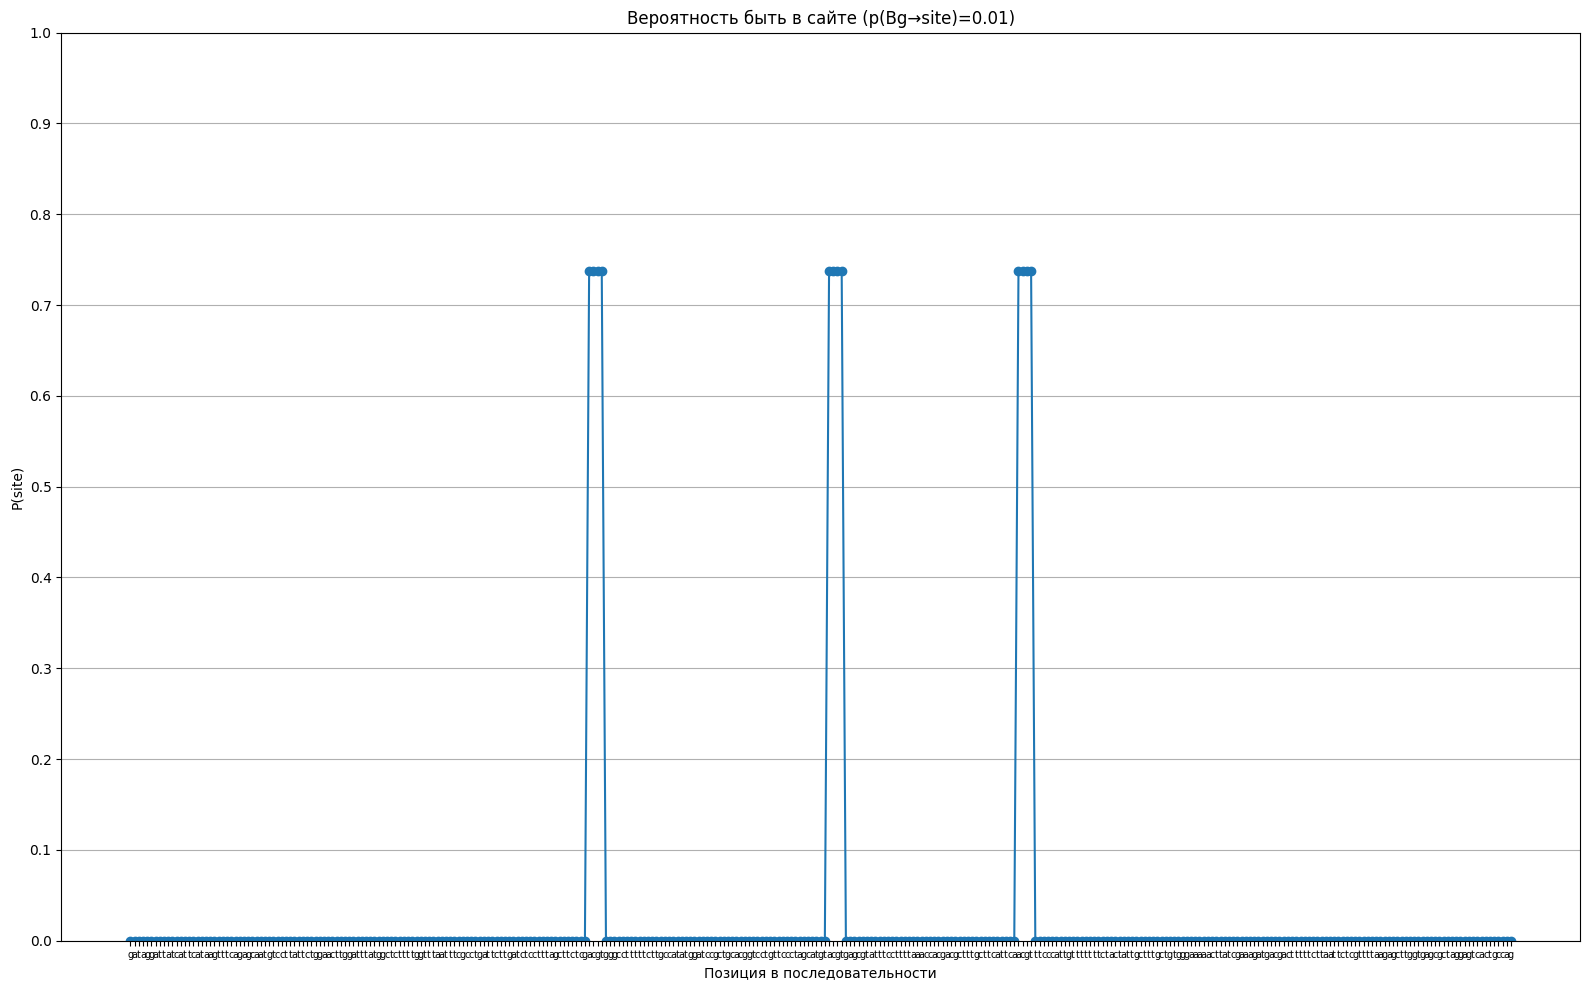

In [7]:
#setting transition probabilities Bg->site=0.00001
def get_transitions(p=0.00001):
    return {
        'Bg': {'Bg': 1 - p - 0.01, 'S1': p},
        'S1': {'S2': 1.0},
        'S2': {'S3': 1.0},
        'S3': {'S4': 1.0},
        'S4': {'Bg': 0.99},
    }

#algorithm forward
def forward(seq, transitions, emission):
    T = len(seq)
    alpha = {s: np.zeros(T) for s in states}
    alpha['Bg'][0] = emission['Bg'][seq[0]]

    for t in range(1, T):
        for curr in states:
            total = 0
            for prev in states:
                if prev in transitions and curr in transitions[prev]:
                    total += alpha[prev][t-1] * transitions[prev][curr]
            alpha[curr][t] = total * emission[curr].get(seq[t], 0)
    return alpha

#algorithm backward
def backward(seq, transitions, emission):
    T = len(seq)
    beta = {s: np.zeros(T) for s in states}
    for s in states:
        beta[s][T-1] = 1

    for t in reversed(range(T-1)):
        for curr in states:
            total = 0
            for next_s in states:
                if curr in transitions and next_s in transitions[curr]:
                    trans = transitions[curr][next_s]
                    emit = emission[next_s].get(seq[t+1], 0)
                    total += trans * emit * beta[next_s][t+1]
            beta[curr][t] = total
    return beta

#forward-backward
def forward_backward(seq, p_bg_to_site=0.00001):
    transitions = get_transitions(p_bg_to_site)
    alpha = forward(seq, transitions, emission)
    beta = backward(seq, transitions, emission)
    T = len(seq)
    gamma = {s: np.zeros(T) for s in states}
    for t in range(T):
        norm = sum(alpha[s][t] * beta[s][t] for s in states)
        for s in states:
            gamma[s][t] = (alpha[s][t] * beta[s][t]) / (norm if norm > 0 else 1e-12)
    return gamma

#graph
def plot_site_probabilities(seq, p=0.00001):
    gamma = forward_backward(seq, p)
    site_probs = [sum(gamma[s][t] for s in ['S1', 'S2', 'S3', 'S4']) for t in range(len(seq))]

    plt.figure(figsize=(16, 10))
    plt.plot(site_probs, marker='o')
    plt.xticks(ticks=range(len(seq)), labels=seq, fontsize=7)
    plt.yticks(np.linspace(0, 1, 11))
    plt.title(f"Вероятность быть в сайте (p(Bg→site)={p})")
    plt.xlabel("Позиция в последовательности")
    plt.ylabel("P(site)")
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

plot_site_probabilities(seq, p=0.01)  # можно изменить p=0.001 или другое

По идее, при снижении вероятности перехода из фона в сайт понижается вероятность того, что мы в сайте на графе.

##Генерация последовательности



In [8]:
states = ['Bg', 'S1', 'S2', 'S3', 'S4']
alphabet = ['a', 'c', 'g', 't']

#emissions
emission = {
    'Bg': ['a', 'c', 'g', 't'],
    'S1': ['a'],
    'S2': ['c'],
    'S3': ['g'],
    'S4': ['t'],
}
emission_probs = {
    'Bg': [0.25, 0.25, 0.25, 0.25],
    'S1': [1.0],
    'S2': [1.0],
    'S3': [1.0],
    'S4': [1.0],
}

#transitions
def get_transitions(p=0.01):
    return {
        'Bg': ['Bg', 'S1'],
        'S1': ['S2'],
        'S2': ['S3'],
        'S3': ['S4'],
        'S4': ['Bg'],
    }, {
        'Bg': [1 - p, p],      # ← Сумма = 1.0
        'S1': [1.0],
        'S2': [1.0],
        'S3': [1.0],
        'S4': [0.99],  # или [1.0] если без выхода в E
    }

#generating sequence
def generate_sequence(length=50, p=0.01):
    trans_states, trans_probs = get_transitions(p)
    state = 'Bg'
    seq = []
    path = []

    for _ in range(length):
        #symbol generation
        symbol = np.random.choice(emission[state], p=emission_probs[state])
        seq.append(symbol)
        path.append(state)

        #transition to next state
        next_states = trans_states[state]
        probs = trans_probs[state]
        probs = np.array(probs)
        probs = probs / probs.sum()
        state = np.random.choice(next_states, p=probs)

    return ''.join(seq), path

sequence, states = generate_sequence(length=100, p=0.01)
print("Sequence: ", sequence)
print("States:", ''.join(states))

Sequence:  gctgctctccgcctcgacactgtgaccgtaccaattgagcgtgattcgaaggaacccataactgctgtcaaactttacactgtagggcgttgtcgggctg
States: BgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBgBg
